In [1]:
# load libraies

%run py_libraries.py

/Users/4476224/.local/lib/python3.8/site-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.6.0 and strictly below 2.9.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.13.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're using a tested and supported configuration, either change the TensorFlow version or the TensorFlow Addons's version. 
You can find the compatibility matrix in TensorFlow Addon's readme:
https://github.com/tensorflow/addons
  warnings.warn(


In [2]:
# loading utility files

from utility.sv_fig import savefig

In [3]:
# load data
data = pd.read_csv('data/baselinedata_37F.csv')
# data = data.loc[0:317]

# print(data.shape)
data = data.apply(pd.to_numeric) # convert all columns of Ndata to numerics

# PCa v Ca
ndata_PCa_Ca = data[data["CACHEXSTAGE0VIG"] != 0]
ndata_PCa_Ca.reset_index(drop=True, inplace=True)
print(ndata_PCa_Ca.shape)

# Replace all occurrences of 2 with 0
ndata_PCa_Ca["CACHEXSTAGE0VIG"] = ndata_PCa_Ca["CACHEXSTAGE0VIG"].replace(2, 0)

X = ndata_PCa_Ca.iloc[:,:-1]
y = ndata_PCa_Ca.iloc[:, -1] #.values

# X.head()

def data_split(X,y,rnd_st,tst_sz):
    X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                        test_size = tst_sz, 
                                                        random_state=rnd_st,
                                                        stratify=y)
    
    return X_train, X_test, y_train, y_test

#

X_train, X_test, y_train, y_test = data_split(X,y,rnd_st=1234,tst_sz=0.30)        # working best for now
# X_train, X_test, y_train, y_test = data_split(X,y,rnd_st=1234,tst_sz=0.20)        # working best for now



(156, 38)


In [4]:
# Boxplot for training data, testing data, ext validation data


bx_trn = pd.concat([X_train,y_train], axis=1)
bx_tst = pd.concat([X_test,y_test], axis=1)

bx_trn['CACHEXSTAGE0VIG'] = bx_trn['CACHEXSTAGE0VIG'].replace(to_replace=1.0,value="PCa")
bx_trn['CACHEXSTAGE0VIG'] = bx_trn['CACHEXSTAGE0VIG'].replace(to_replace=0.0,value="Ca")

bx_tst['CACHEXSTAGE0VIG'] = bx_tst['CACHEXSTAGE0VIG'].replace(to_replace=1.0,value="PCa")
bx_tst['CACHEXSTAGE0VIG'] = bx_tst['CACHEXSTAGE0VIG'].replace(to_replace=0.0,value="Ca")


# print(bx_trn)
# print(bx_tst)

In [5]:
print(bx_trn.shape)
print(bx_tst.shape)

(109, 38)
(47, 38)


In [6]:
# Training 
# 'IFN.y', 'MIP.1a', 'Glucose', 'IL.10'

# Table 1 (Ca)
data_ca_trn = {
    "IFN.y": bx_trn.loc[bx_trn['CACHEXSTAGE0VIG'] == "Ca", 'IFN.y'].tolist(),
    "MIP.1a": bx_trn.loc[bx_trn['CACHEXSTAGE0VIG'] == "Ca", 'MIP.1a'].tolist(),
    "Glucose": bx_trn.loc[bx_trn['CACHEXSTAGE0VIG'] == "Ca", 'Glucose'].tolist(),
    "IL.10": bx_trn.loc[bx_trn['CACHEXSTAGE0VIG'] == "Ca", 'IL.10'].tolist(),
}
df_ca_trn = pd.DataFrame(data_ca_trn)

# Table 2 (PCa)
data_pca_trn = {
    "IFN.y": bx_trn.loc[bx_trn['CACHEXSTAGE0VIG'] == "PCa", 'IFN.y'].tolist(),
    "MIP.1a": bx_trn.loc[bx_trn['CACHEXSTAGE0VIG'] == "PCa", 'MIP.1a'].tolist(),
    "Glucose": bx_trn.loc[bx_trn['CACHEXSTAGE0VIG'] == "PCa", 'Glucose'].tolist(),
    "IL.10": bx_trn.loc[bx_trn['CACHEXSTAGE0VIG'] == "PCa", 'IL.10'].tolist(),
}
df_pca_trn = pd.DataFrame(data_pca_trn)


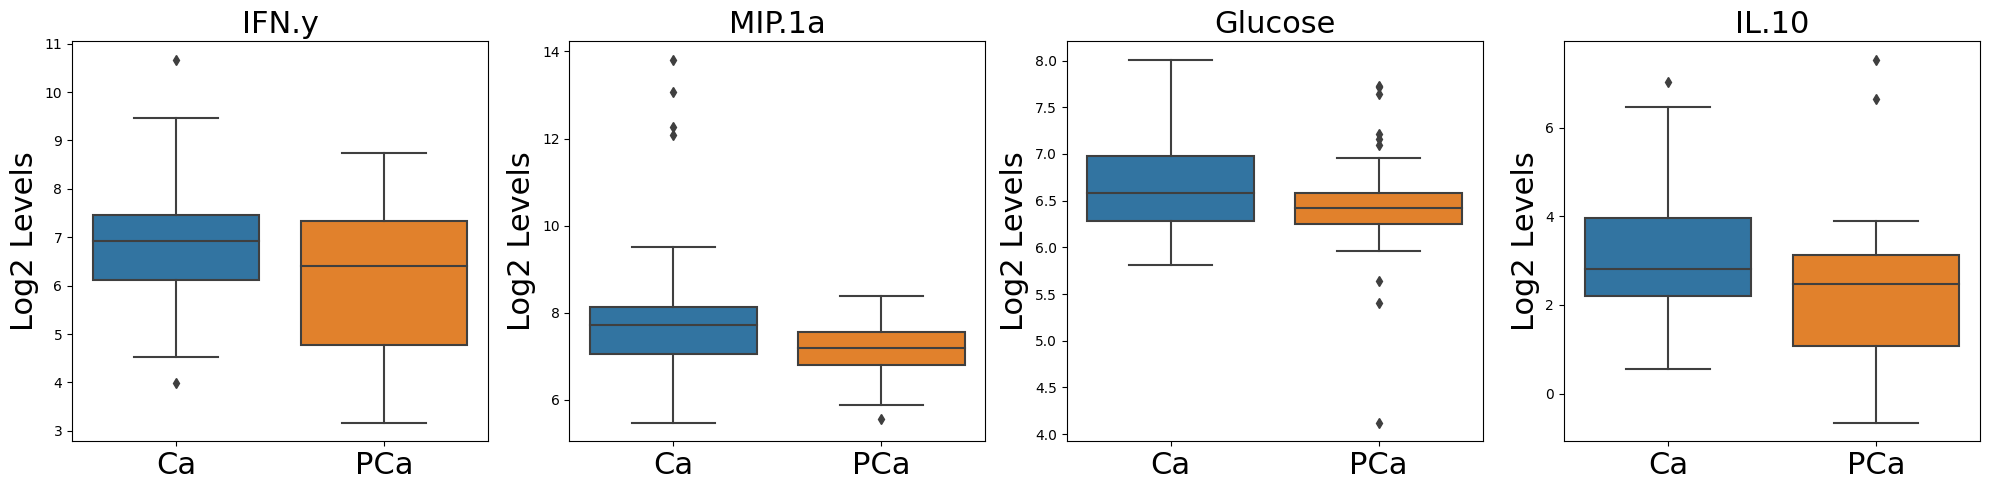

In [7]:
tablec_trn = df_ca_trn.copy()   # Ca
tablep_trn = df_pca_trn.copy()   # PCa

# Add labels for each group
tablec_trn["Group"] = "Ca"
tablep_trn["Group"] = "PCa"

# Combine into one dataset
df = pd.concat([tablec_trn, tablep_trn], ignore_index=True)

# Get feature names (exclude 'Group')
features = [col for col in df.columns if col != "Group"]

# Create subplots
n_features = len(features)
fig, axes = plt.subplots(1, n_features, figsize=(5*n_features, 5), sharey=False)

for i, feature in enumerate(features):
    sns.boxplot(data=df, x="Group", y=feature, ax=axes[i])
    axes[i].set_title(feature, fontdict={'size': 22})
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Log2 Levels", fontdict={'size': 22})
    axes[i].set_xticklabels(axes[i].get_xticklabels(), fontsize=22)

plt.tight_layout()
# plt.show()

savefig('./figs/Feat_distri_trn')


In [8]:
# Testing 
# 'IFN.y', 'MIP.1a', 'Glucose', 'IL.10'

# Table 1 (Ca)
data_ca_tst = {
    "IFN.y": bx_tst.loc[bx_tst['CACHEXSTAGE0VIG'] == "Ca", 'IFN.y'].tolist(),
    "MIP.1a": bx_tst.loc[bx_tst['CACHEXSTAGE0VIG'] == "Ca", 'MIP.1a'].tolist(),
    "Glucose": bx_tst.loc[bx_tst['CACHEXSTAGE0VIG'] == "Ca", 'Glucose'].tolist(),
    "IL.10": bx_tst.loc[bx_tst['CACHEXSTAGE0VIG'] == "Ca", 'IL.10'].tolist(),
}
df_ca_tst = pd.DataFrame(data_ca_tst)

# Table 2 (PCa)
data_pca_tst = {
    "IFN.y": bx_tst.loc[bx_tst['CACHEXSTAGE0VIG'] == "PCa", 'IFN.y'].tolist(),
    "MIP.1a": bx_tst.loc[bx_tst['CACHEXSTAGE0VIG'] == "PCa", 'MIP.1a'].tolist(),
    "Glucose": bx_tst.loc[bx_tst['CACHEXSTAGE0VIG'] == "PCa", 'Glucose'].tolist(),
    "IL.10": bx_tst.loc[bx_tst['CACHEXSTAGE0VIG'] == "PCa", 'IL.10'].tolist(),
}
df_pca_tst = pd.DataFrame(data_pca_tst)


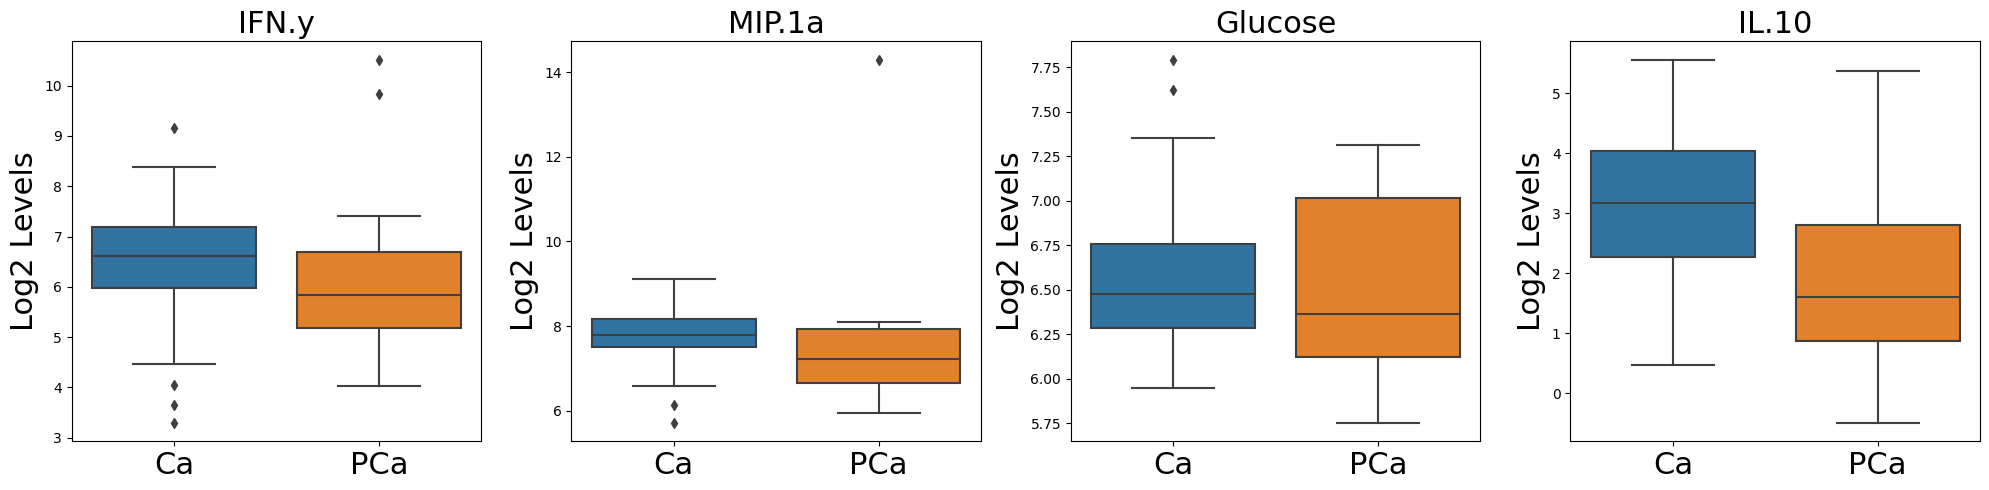

In [9]:
tablec_tst = df_ca_tst.copy()   # Ca
tablep_tst = df_pca_tst.copy()   # PCa

# Add labels for each group
tablec_tst["Group"] = "Ca"
tablep_tst["Group"] = "PCa"

# Combine into one dataset
df = pd.concat([tablec_tst, tablep_tst], ignore_index=True)

# Get feature names (exclude 'Group')
features = [col for col in df.columns if col != "Group"]

# Create subplots
n_features = len(features)
fig, axes = plt.subplots(1, n_features, figsize=(5*n_features, 5), sharey=False)

for i, feature in enumerate(features):
    sns.boxplot(data=df, x="Group", y=feature, ax=axes[i])
    axes[i].set_title(feature, fontdict={'size': 22})
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Log2 Levels", fontdict={'size': 22})
    axes[i].set_xticklabels(axes[i].get_xticklabels(), fontsize=22)

plt.tight_layout()
# plt.show()

savefig('./figs/Feat_distri_tst')
